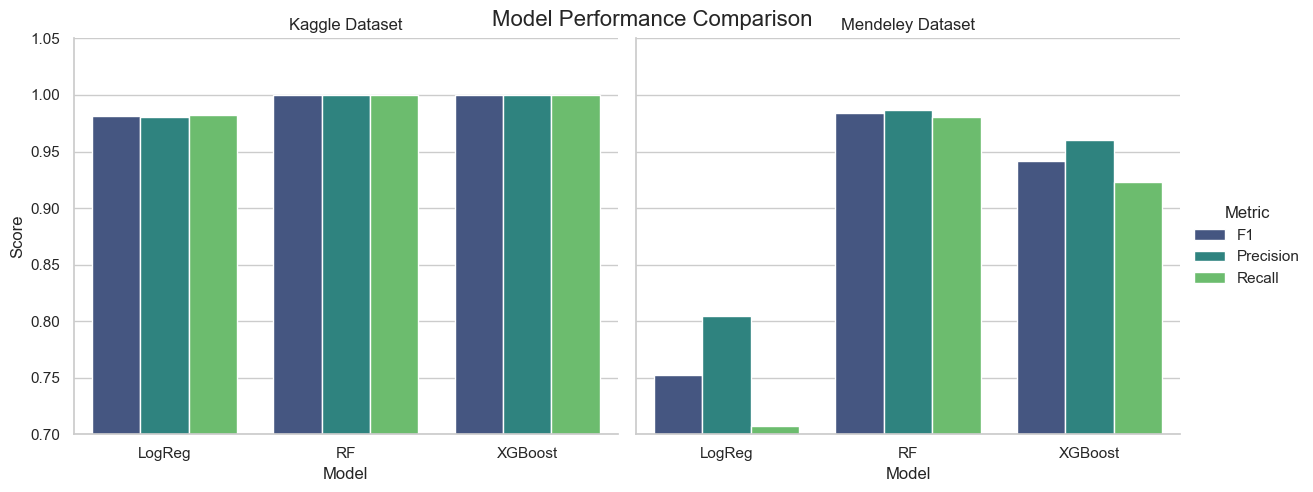

C:\Users\rimsh\AppData\Local\Temp\ipykernel_16580\1841544453.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g2 = sns.catplot(


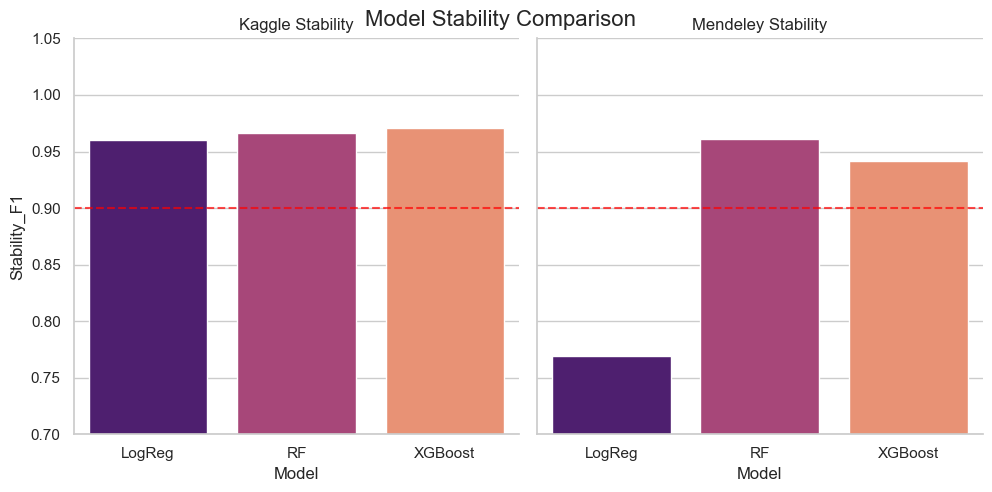

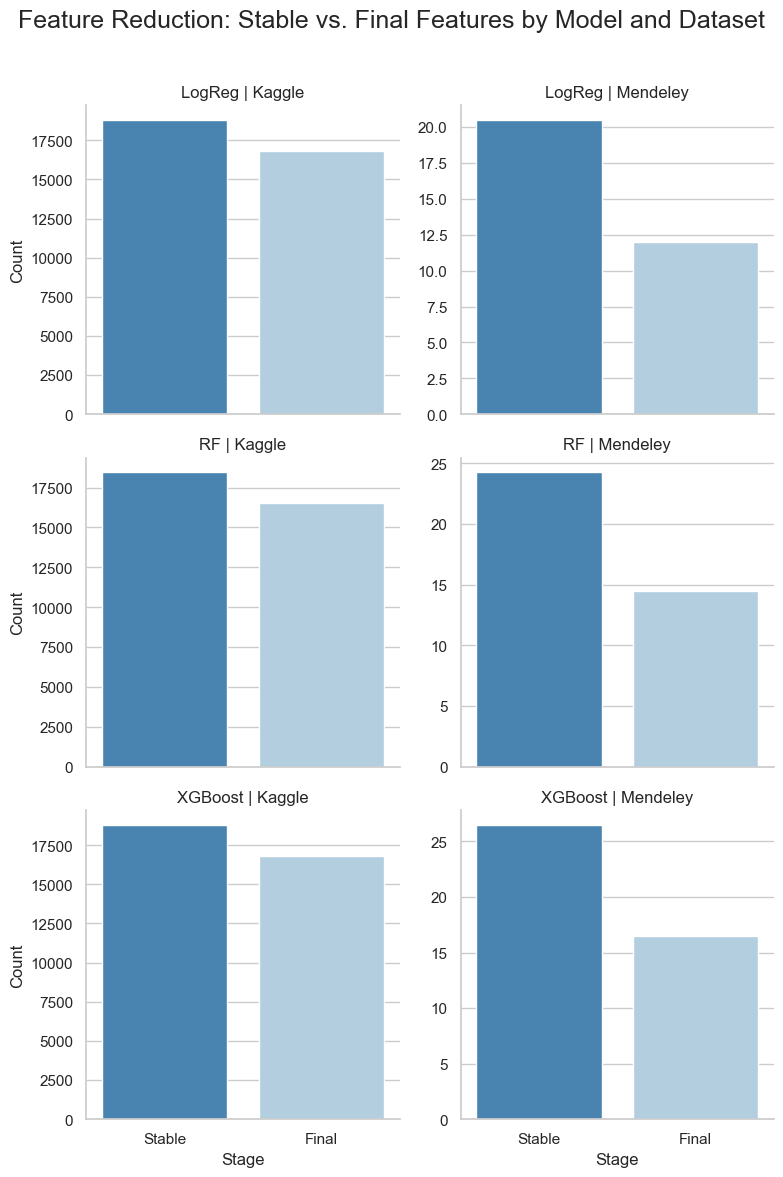

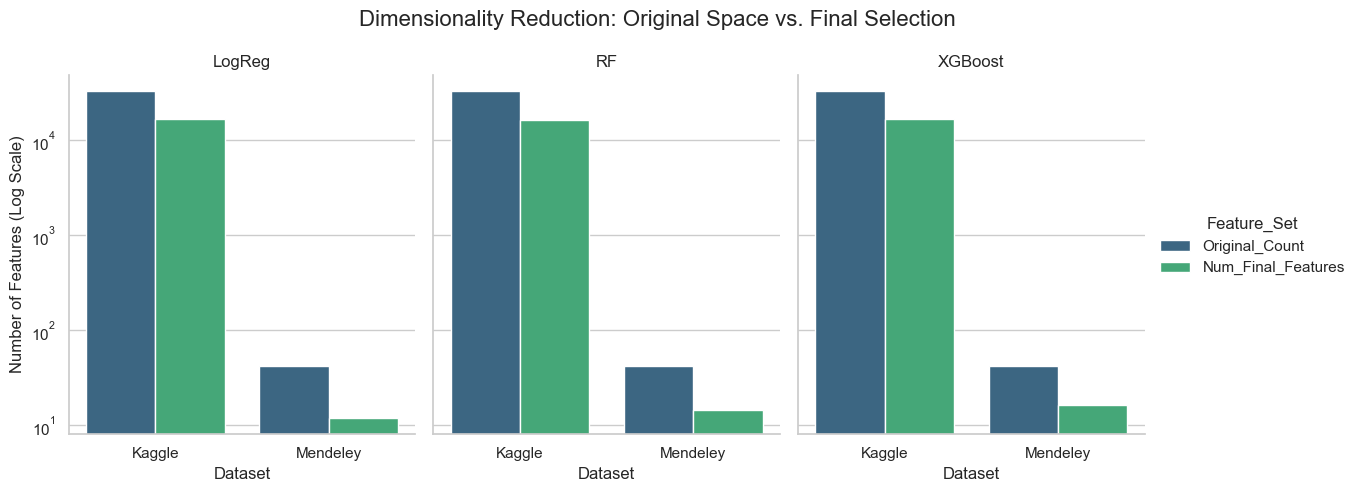

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
# 1. Load data
path = r"..\results\phase_3\final_reports\final_results_*.csv"
files = glob.glob(path) 
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

sns.set_theme(style="whitegrid")

# --- PLOT 1: Performance (Separated by Dataset) ---
df_perf = df.melt(id_vars=['Dataset', 'Model'], 
                   value_vars=['F1', 'Precision', 'Recall'], 
                   var_name='Metric', value_name='Score')

g1 = sns.catplot(
    data=df_perf, kind="bar",
    x="Model", y="Score", hue="Metric",
    col="Dataset", palette="viridis", 
    height=5, aspect=1.2,
    errorbar=None 
)

g1.set_titles("{col_name} Dataset")
g1.fig.suptitle("Model Performance Comparison", fontsize=16)
# Lowering the bottom limit to 0.8 (or 0.0) so lower scores are visible
g1.set(ylim=(0.7, 1.05)) 

plt.savefig('performance_summary.png', dpi=300)
plt.show()

# --- PLOT 2: Stability (Separated by Dataset) ---
g2 = sns.catplot(
    data=df, kind="bar",
    x="Model", y="Stability_F1",
    col="Dataset", palette="magma", height=5, aspect=1, errorbar=None 
)
g2.set_titles("{col_name} Stability")
# Adding the threshold line to each subplot
for ax in g2.axes.flat:
    ax.axhline(0.9, color='red', linestyle='--', alpha=0.7)
    ax.set_ylim(0.7, 1.05)  # Adjust y-axis limits to better visualize differences
plt.savefig('stability_by_dataset.png', dpi=300)
g2.fig.suptitle("Model Stability Comparison", fontsize=16)
plt.show()

# --- PLOT 3: Feature Counts (6-Plot Grid) ---
# Melt the dataframe to have a long format suitable for hue comparison
df_feat = df.melt(id_vars=['Dataset', 'Model'], 
                  value_vars=['Num_Stable_Features', 'Num_Final_Features'], 
                  var_name='Stage', value_name='Count')

# Using catplot with col and row to create the 6-plot matrix
g3 = sns.catplot(
    data=df_feat, 
    kind="bar",
    x="Stage",         # Stages on X-axis for better side-by-side comparison
    y="Count",  
    hue="Stage",       # Different colors for Stable vs Final
    col="Dataset",     # Creates columns for Kaggle and Mendeley
    row="Model",       # Creates rows for XGBoost, Random Forest, Logistic Regression
    palette="Blues_r", 
    height=4, 
    aspect=1, 
    sharey=False,      # Important: Datasets have vastly different scales
    errorbar=None 
)

# Refine labels and titles
g3.set_titles("{row_name} | {col_name}")
g3.set_xticklabels(["Stable", "Final"])
g3.fig.subplots_adjust(top=0.9)
g3.fig.suptitle("Feature Reduction: Stable vs. Final Features by Model and Dataset", fontsize=18)

# Save the grid
plt.savefig('feature_reduction_matrix.png', dpi=300, bbox_inches='tight')

plt.show()

# --- PLOT 4: Total Feature Reduction (Original vs. Final) ---
# Assuming 'Original_Count' is the total features after Hashing Vectorization (e.g., 32034)
# and 'Num_Final_Features' is the result of your Phase 3 algorithm.
original_counts = {
    'Kaggle': 32856,
    'Mendeley': 42
}

# 2. Add the original count to your dataframe for plotting
df['Original_Count'] = df['Dataset'].map(original_counts)

df_total = df.melt(id_vars=['Dataset', 'Model'], 
                   value_vars=['Original_Count', 'Num_Final_Features'], 
                   var_name='Feature_Set', value_name='Count')

g4 = sns.catplot(
    data=df_total, 
    kind="bar",
    x="Dataset", 
    y="Count", 
    hue="Feature_Set", 
    col="Model", 
    palette="viridis", 
    height=5, 
    aspect=0.8,
    errorbar = None,
    sharey=True # Keeping sharey=True here helps show the scale of the reduction
)
# 5. Apply Log Scale to Y-axis
for ax in g4.axes.flat:
    ax.set_yscale("log")
    ax.set_ylabel("Number of Features (Log Scale)")

# 6. Formatting
g4.set_titles("{col_name}")
g4.set_xticklabels(["Kaggle", "Mendeley"])
g4.fig.subplots_adjust(top=0.85)
g4.fig.suptitle("Dimensionality Reduction: Original Space vs. Final Selection", fontsize=16)
plt.savefig('original_vs_final_features.png', dpi=300, bbox_inches='tight')
plt.show()